【 사용 데이터 】

1. 서울시 부동산 중개업소 정보 (JSON)
   - 출처: 서울시 공공데이터
   - 활용 정보: 중개업소 주소 (구 이름 추출)
   - 데이터 규모: 25,450개 중개업소

2. 중개업소 행정처분 통계 (CSV)
   - 출처: 국토교통부
   - 활용 정보: 등록취소, 업무정지, 적발건수
   - 기간: 2017년~현재 (분기별 3,355건)

3. 지역별 부동산 경매 통계 (Excel)
   - 출처: 법원 경매 통계
   - 활용 정보: 동별 경매건수
   - 범위: 서울시 25개 구 (동별 353건 데이터를 구별로 합산)


【 분석 지표 】

1. 경매건수 (40%)
   - 구로구 1,960건 (최다) ~ 용산구 372건 (최소)
   - 경매가 많다 = 시장 불안정 = 급매물/사기 매물 가능성 높음

2. 중개업소 행정처분 비율 (60%)
   - 등록취소 5점, 업무정지 3점, 적발 1점으로 계산
   - 행정처분 점수 ÷ 중개업소 수 = 행정처분 비율
   - 처벌이 많다 = 중개업소 신뢰도 낮음 = 허위매물 가능성 높음


【 계산 과정 】

1. 데이터 전처리
   - 중개업소 주소에서 '서울특별시 ○○구' 패턴으로 구 이름 추출
   - 동별 경매건수를 구별로 합산 (예: 강남구 = 개포동 + 논현동 + 대치동 + ...)
   - 2017~현재 행정처분 데이터를 구별로 집계

2. 구별 점수 계산
   - 각 구의 중개업소 수 집계 (강남구 3,027개 ~ 도봉구 474개)
   - 행정처분 점수 = (등록취소 × 5) + (업무정지 × 3) + (적발건수 × 1)
   - 행정처분 비율 = 행정처분 점수 ÷ 중개업소 수

3. 정규화 (Min-Max Scaling, 0~100점)
   - 행정처분 비율: 0.098 ~ 1.013 → 0~100점으로 변환
   - 경매건수: 372 ~ 1,960건 → 0~100점으로 변환
   - 목적: 단위가 다른 지표를 공정하게 비교

4. 가중합 계산
   허위매물 온도 = (행정처분 정규화 점수 × 0.6) + (경매건수 정규화 점수 × 0.4)
   
   예시 (강남구):
   - 행정처분 비율: 0.361 → 정규화 28.72점
   - 경매건수: 1,250건 → 정규화 55.28점
   - 허위매물 온도 = (28.72 × 0.6) + (55.28 × 0.4) = 39.35점

5. 등급 분류
   - 0~33점: 안전 (13개 구)
   - 33~66점: 주의 (11개 구)
   - 66~100점: 고위험 (1개 구 - 중구 82.17점)


## 1. 데이터 로드

In [1]:
import pandas as pd
import json
import glob
import os

In [2]:
# 1. 서울시 부동산 중개업소 정보 JSON 읽기
with open('../data/regionTemp/서울시 부동산 중개업소 정보.json', 'r', encoding='utf-8') as f:
    broker_data = json.load(f)

broker_df = pd.DataFrame(broker_data['DATA'])
print("=== 서울시 부동산 중개업소 정보 ===")
print(f"데이터 shape: {broker_df.shape}")
print(broker_df.head())

=== 서울시 부동산 중개업소 정보 ===
데이터 shape: (25450, 21)
  pbadms_dsps_end_dd pbadms_dsps_strt_dd stts_se sgg_cd mdt_bsns_nm  \
0               None                None     영업중  11440         김은정   
1               None                None     영업중  11680         오해숙   
2               None                None     영업중  11680         양신숙   
3               None                None     영업중  11680         정경표   
4               None                None     영업중  11680         박규리   

        sys_reg_no   sno                                              telno  \
0  114402022000106  0000                                        02-718-3636   
1  116802022000266  0000                                      , 02-562-6985   
2  116802022000269  0000                                        02-572-8880   
3  116802022000259  0019                                        02-552-0113   
4  116802022000253  0000  02-512-2232, 02-547-2227, 02-518-2232, 02-515-...   

  lotno_se                                         

In [3]:
# 2. 행정처분 CSV 읽기
try:
    penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='cp949')
    except UnicodeDecodeError:
        penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='euc-kr')

print("\n=== 행정처분 정보 ===")
print(f"데이터 shape: {penalty_df.shape}")
print(penalty_df.head())


=== 행정처분 정보 ===
데이터 shape: (3355, 10)
     년도  분기    시도명 시군구명  단속업소수  적발건수  고발센터신고건수  계  등록취소  업무정지
0  2017   1  서울특별시   중구      4     4         0  4     1     2
1  2017   1  서울특별시  성동구      0     1         1  1     0     1
2  2017   1  서울특별시  광진구      0     3         0  3     1     0
3  2017   1  서울특별시  중랑구      0     1         0  1     0     0
4  2017   1  서울특별시  강북구      0     2         0  2     1     1


In [4]:
# 3. 모든 구의 매각통계 파일 읽기
sale_files = glob.glob('../data/regionTemp/saleLand/지역별 매각통계_*.xls')

sale_dfs = []
for file_path in sale_files:
    region_name = os.path.basename(file_path).replace('지역별 매각통계_', '').replace('.xls', '')
    
    df = pd.read_excel(file_path, engine='xlrd')
    df['region'] = region_name
    sale_dfs.append(df)

sale_df = pd.concat(sale_dfs, ignore_index=True)

# 경매건수를 숫자로 변환
sale_df['경매건수'] = pd.to_numeric(sale_df['경매건수'], errors='coerce')

print("\n=== 지역별 매각통계 (전체 구) ===")
print(f"총 {len(sale_files)}개 구 데이터 로드 완료")
print(f"전체 데이터 shape: {sale_df.shape}")

# 구별 경매건수 확인
print("\n구별 경매건수:")
region_auction = sale_df.groupby('region')['경매건수'].sum().sort_values(ascending=False)
for region, count in region_auction.items():
    print(f"  {region}: {int(count)}건")



=== 지역별 매각통계 (전체 구) ===
총 25개 구 데이터 로드 완료
전체 데이터 shape: (353, 8)

구별 경매건수:
  구로구: 1960건
  성북구: 1800건
  관악구: 1754건
  동작구: 1754건
  중랑구: 1694건
  강북구: 1636건
  금천구: 1550건
  도봉구: 1538건
  송파구: 1502건
  은평구: 1345건
  서초구: 1338건
  서대문구: 1324건
  중구: 1252건
  강남구: 1250건
  강서구: 1173건
  강동구: 1166건
  영등포구: 1114건
  마포구: 998건
  노원구: 994건
  동대문구: 980건
  광진구: 866건
  양천구: 752건
  종로구: 718건
  성동구: 520건
  용산구: 372건


## 2. 데이터 전처리 및 분석

In [5]:
# 중개업소 정보에서 구 이름 추출
broker_df['region'] = broker_df['addr'].str.extract(r'서울특별시\s*(\S+구)')

# 지역별 중개업소 수
office_count = broker_df.groupby('region').size().reset_index(name='office_count')
print("지역별 중개업소 수:")
print(office_count.sort_values('office_count', ascending=False))

지역별 중개업소 수:
   region  office_count
0     강남구          3027
14    서초구          1847
17    송파구          1772
1     강동구          1305
3     강서구          1291
12    마포구          1226
19   영등포구          1143
21    은평구          1052
10   동대문구           982
4     관악구           963
5     광진구           896
18    양천구           892
20    용산구           881
15    성동구           854
11    동작구           834
16    성북구           806
6     구로구           766
24    중랑구           727
8     노원구           726
13   서대문구           680
7     금천구           619
23     중구           600
2     강북구           562
22    종로구           525
9     도봉구           474


In [6]:
# 행정처분 점수 계산 (등록취소=5점, 업무정지=3점, 적발건수=1점)
penalty_df['penalty_score'] = (
    penalty_df['등록취소'] * 5 +
    penalty_df['업무정지'] * 3 +
    penalty_df['적발건수'] * 1
)

# 지역별 행정처분 점수 합계
penalty_grouped = penalty_df.groupby('시군구명')['penalty_score'].sum().reset_index()
penalty_grouped.rename(columns={'시군구명':'region'}, inplace=True)
print("\n지역별 행정처분 점수:")
print(penalty_grouped.sort_values('penalty_score', ascending=False))


지역별 행정처분 점수:
    region  penalty_score
86      서구           1852
1      강남구           1092
208    화성시            917
30     구미시            817
39     김포시            791
..     ...            ...
148    울진군              4
190    태백시              4
159    장성군              1
163    정선군              1
204    해남군              1

[211 rows x 2 columns]


In [7]:
# 경매 데이터를 구별로 합산
auction_grouped = sale_df.groupby('region')['경매건수'].sum().reset_index()
print(f"\n경매 데이터가 있는 구: {len(auction_grouped)}개")
print(auction_grouped.sort_values('경매건수', ascending=False))


경매 데이터가 있는 구: 25개
   region    경매건수
6     구로구  1960.0
16    성북구  1800.0
4     관악구  1754.0
11    동작구  1754.0
24    중랑구  1694.0
2     강북구  1636.0
7     금천구  1550.0
9     도봉구  1538.0
17    송파구  1502.0
21    은평구  1345.0
14    서초구  1338.0
13   서대문구  1324.0
23     중구  1252.0
0     강남구  1250.0
3     강서구  1173.0
1     강동구  1166.0
19   영등포구  1114.0
12    마포구   998.0
8     노원구   994.0
10   동대문구   980.0
5     광진구   866.0
18    양천구   752.0
22    종로구   718.0
15    성동구   520.0
20    용산구   372.0


In [8]:
# 3개 지표 병합
merged = office_count.merge(penalty_grouped, on='region', how='left')
merged = merged.merge(auction_grouped, on='region', how='left')

# 행정처분 비율 계산
merged['penalty_ratio'] = merged['penalty_score'] / merged['office_count']

print("\n병합된 데이터:")
print(merged.head(10))


병합된 데이터:
  region  office_count  penalty_score    경매건수  penalty_ratio
0    강남구          3027           1092  1250.0       0.360753
1    강동구          1305            177  1166.0       0.135632
2    강북구           562            241  1636.0       0.428826
3    강서구          1291            681  1173.0       0.527498
4    관악구           963            357  1754.0       0.370717
5    광진구           896            116   866.0       0.129464
6    구로구           766            148  1960.0       0.193211
7    금천구           619             71  1550.0       0.114701
8    노원구           726             71   994.0       0.097796
9    도봉구           474             88  1538.0       0.185654


## 3. 허위매물 온도 계산

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max 정규화 (0-100 범위)
scaler = MinMaxScaler(feature_range=(0, 100))
merged[['penalty_norm', 'auction_norm']] = scaler.fit_transform(
    merged[['penalty_ratio', '경매건수']]
)

# 허위온도 계산 (가중합: 행정처분 60%, 경매건수 40%)
merged['fake_temperature'] = (
    merged['penalty_norm'] * 0.6 +
    merged['auction_norm'] * 0.4
)

# 등급 분류
def grade(temp):
    if pd.isna(temp):
        return 'N/A'
    elif temp < 33:
        return '안전'
    elif temp < 66:
        return '주의'
    else:
        return '고위험'

merged['grade'] = merged['fake_temperature'].apply(grade)

print("\n허위매물 온도 계산 완료:")
print(merged[['region', 'office_count', 'penalty_ratio', '경매건수', 'fake_temperature', 'grade']].sort_values('fake_temperature', ascending=False))


허위매물 온도 계산 완료:
   region  office_count  penalty_ratio    경매건수  fake_temperature grade
23     중구           600       1.013333  1252.0         82.166247   고위험
2     강북구           562       0.428826  1636.0         53.532906    주의
4     관악구           963       0.370717  1754.0         52.697000    주의
3     강서구          1291       0.527498  1173.0         48.336965    주의
17    송파구          1772       0.392212  1502.0         47.758119    주의
6     구로구           766       0.193211  1960.0         46.253073    주의
16    성북구           806       0.163772  1800.0         40.293502    주의
11    동작구           834       0.175060  1754.0         39.874590    주의
0     강남구          3027       0.360753  1250.0         39.348839    주의
9     도봉구           474       0.185654  1538.0         35.128068    주의
24    중랑구           727       0.115543  1694.0         34.462815    주의
14    서초구          1847       0.226313  1338.0         32.754880    안전
7     금천구           619       0.114701  1550.0         30.780

## 4. 시각화

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 스타일 설정 (한글 폰트 설정 제거)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("시각화 설정 완료!")


시각화 설정 완료!


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\16869826.py:21: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\16869826.py:21: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\16869826.py:21: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\16869826.py:21: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\16869826.py:21: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\16869826.py:21: UserWarning: Glyph 49569 (\N{HANGUL SYLLABLE SONG}) missing from font(s) Arial.
  plt.t

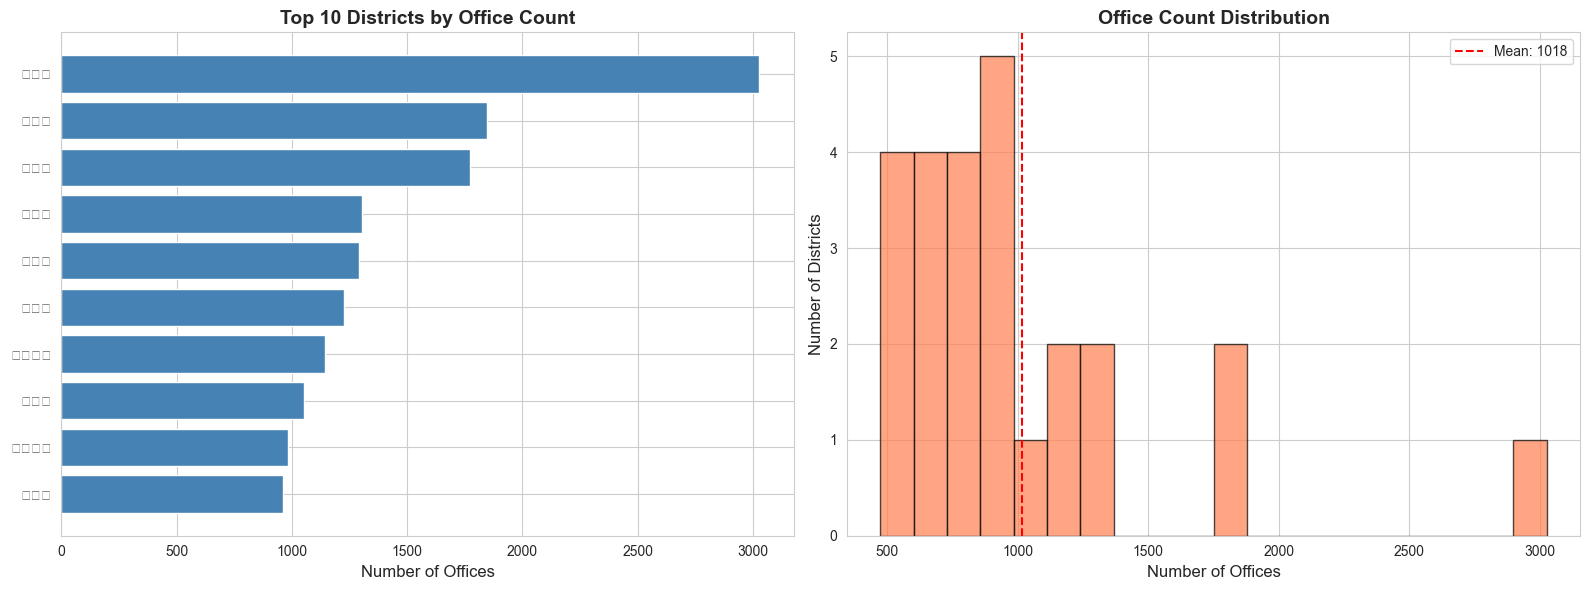

In [17]:
# NaN 제거
merged_clean = merged.dropna(subset=['fake_temperature'])

# 1. 지역별 중개업소 수 분석
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_offices = merged.nlargest(10, 'office_count')
axes[0].barh(top_offices['region'], top_offices['office_count'], color='steelblue')
axes[0].set_xlabel('Number of Offices', fontsize=12)
axes[0].set_title('Top 10 Districts by Office Count', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

axes[1].hist(merged['office_count'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Offices', fontsize=12)
axes[1].set_ylabel('Number of Districts', fontsize=12)
axes[1].set_title('Office Count Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(merged['office_count'].mean(), color='red', linestyle='--', 
                label=f'Mean: {merged["office_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\364345110.py:34: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\364345110.py:34: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\364345110.py:34: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\364345110.py:34: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\364345110.py:34: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\364345110.py:34: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) Aria

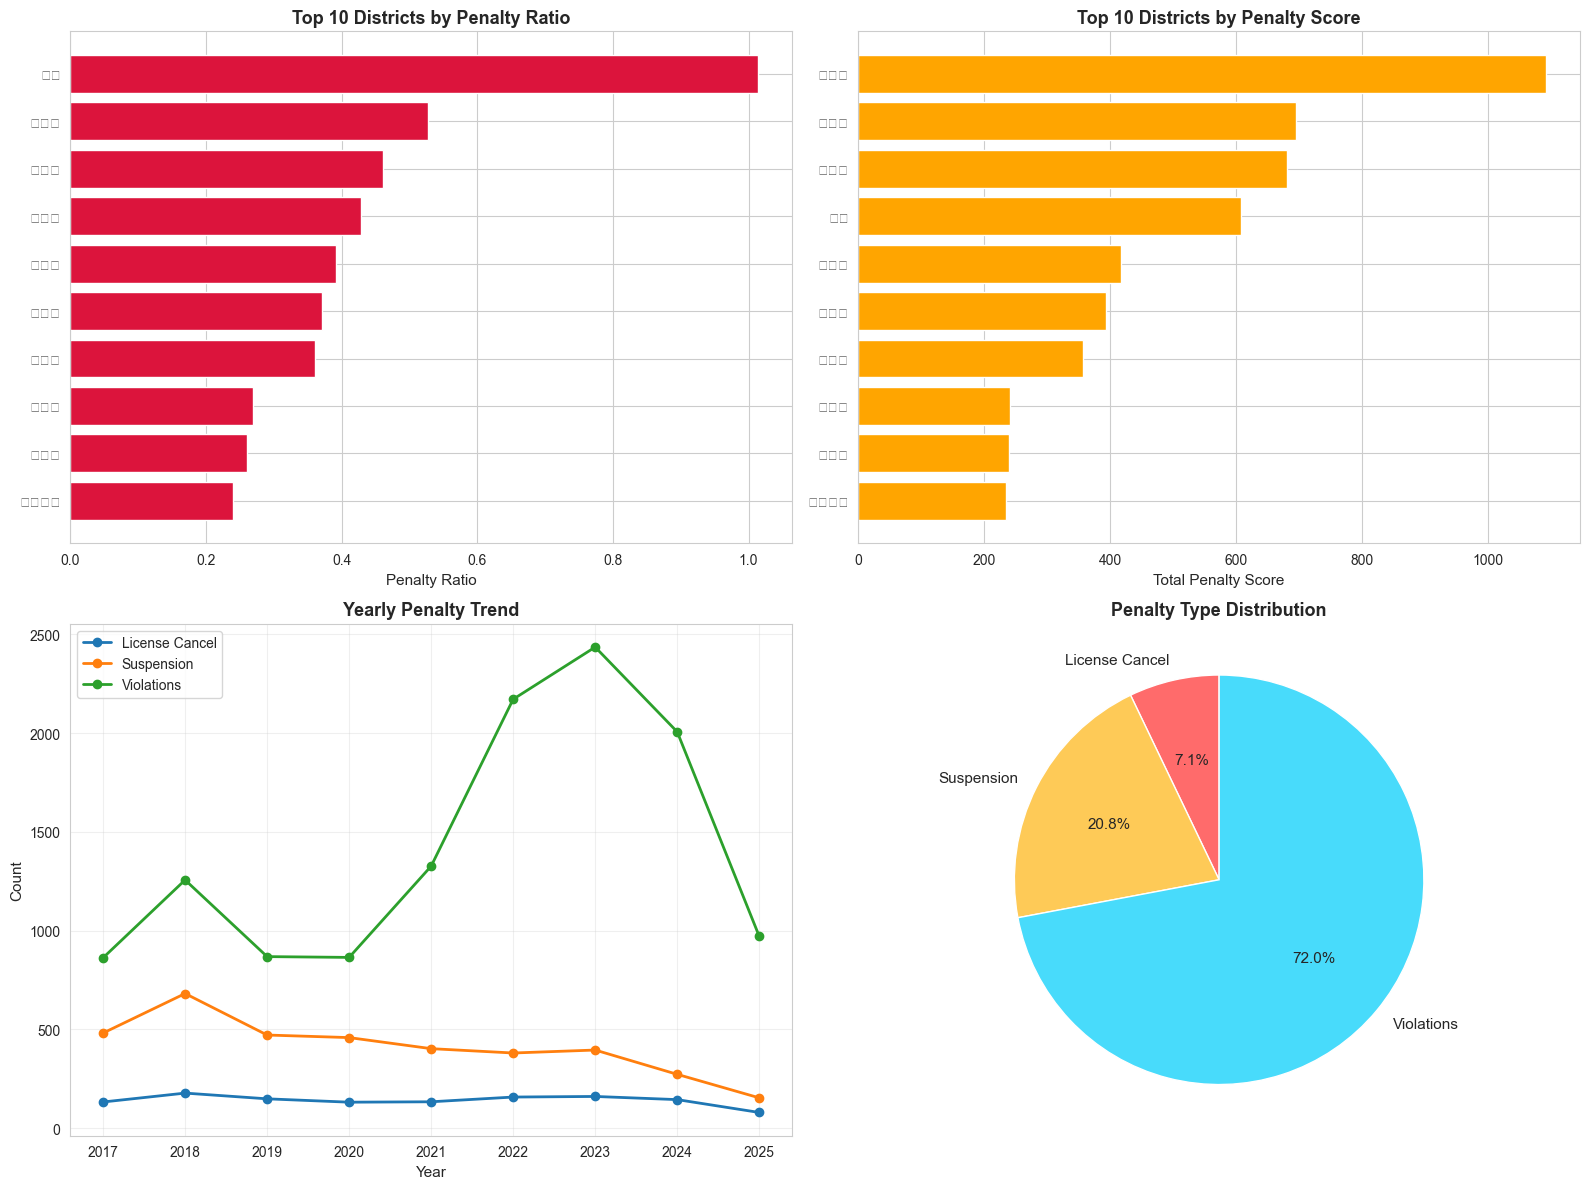

In [18]:
# 2. 행정처분 분석
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 행정처분 비율 TOP 10
top_penalty = merged.nlargest(10, 'penalty_ratio')
axes[0, 0].barh(top_penalty['region'], top_penalty['penalty_ratio'], color='crimson')
axes[0, 0].set_xlabel('Penalty Ratio', fontsize=11)
axes[0, 0].set_title('Top 10 Districts by Penalty Ratio', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()

# 행정처분 총점 TOP 10
top_penalty_score = merged.nlargest(10, 'penalty_score')
axes[0, 1].barh(top_penalty_score['region'], top_penalty_score['penalty_score'], color='orange')
axes[0, 1].set_xlabel('Total Penalty Score', fontsize=11)
axes[0, 1].set_title('Top 10 Districts by Penalty Score', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()

# 연도별 행정처분 추이
yearly_penalty = penalty_df.groupby('년도')[['등록취소', '업무정지', '적발건수']].sum()
yearly_penalty.plot(ax=axes[1, 0], marker='o', linewidth=2)
axes[1, 0].set_xlabel('Year', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title('Yearly Penalty Trend', fontsize=13, fontweight='bold')
axes[1, 0].legend(['License Cancel', 'Suspension', 'Violations'])
axes[1, 0].grid(True, alpha=0.3)

# 행정처분 유형별 비율
penalty_types = penalty_df[['등록취소', '업무정지', '적발건수']].sum()
colors = ['#ff6b6b', '#feca57', '#48dbfb']
axes[1, 1].pie(penalty_types, labels=['License Cancel', 'Suspension', 'Violations'], 
               autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1, 1].set_title('Penalty Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\3079201885.py:46: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\3079201885.py:46: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\3079201885.py:46: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\3079201885.py:46: UserWarning: Glyph 48513 (\N{HANGUL SYLLABLE BUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\3079201885.py:46: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_18184\3079201885.py:46: UserWarning: Glyph 50501 (\N{HANGUL SYLLABLE AG}) missing from font(s) A

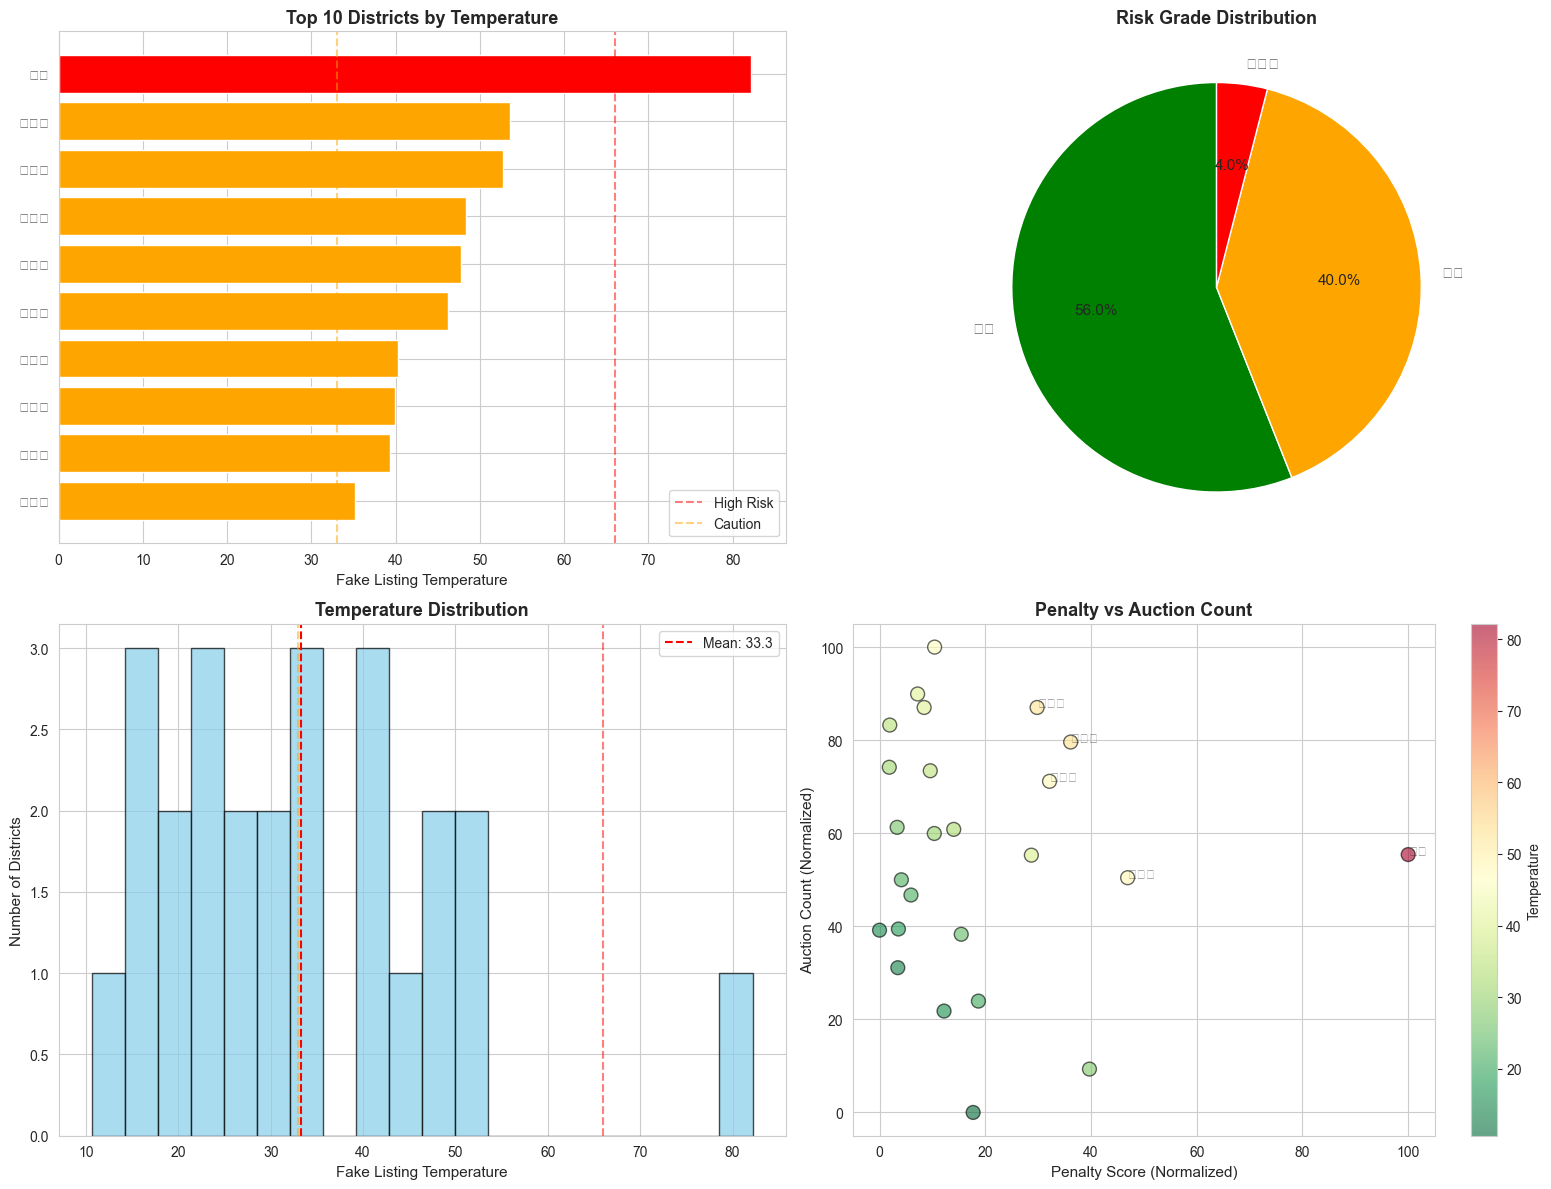

In [19]:
# 3. 허위매물 온도 분석
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 허위매물 온도 TOP 10
top_temp = merged_clean.nlargest(10, 'fake_temperature')
colors_temp = ['red' if x >= 66 else 'orange' if x >= 33 else 'green' for x in top_temp['fake_temperature']]
axes[0, 0].barh(top_temp['region'], top_temp['fake_temperature'], color=colors_temp)
axes[0, 0].set_xlabel('Fake Listing Temperature', fontsize=11)
axes[0, 0].set_title('Top 10 Districts by Temperature', fontsize=13, fontweight='bold')
axes[0, 0].axvline(66, color='red', linestyle='--', alpha=0.5, label='High Risk')
axes[0, 0].axvline(33, color='orange', linestyle='--', alpha=0.5, label='Caution')
axes[0, 0].legend()
axes[0, 0].invert_yaxis()

# 등급별 분포
grade_counts = merged_clean['grade'].value_counts()
colors_grade = ['green', 'orange', 'red']
axes[0, 1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', 
               colors=colors_grade, startangle=90, textprops={'fontsize': 11})
axes[0, 1].set_title('Risk Grade Distribution', fontsize=13, fontweight='bold')

# 온도 분포 히스토그램
axes[1, 0].hist(merged_clean['fake_temperature'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(merged_clean['fake_temperature'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {merged_clean["fake_temperature"].mean():.1f}')
axes[1, 0].axvline(33, color='orange', linestyle='--', alpha=0.5)
axes[1, 0].axvline(66, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Fake Listing Temperature', fontsize=11)
axes[1, 0].set_ylabel('Number of Districts', fontsize=11)
axes[1, 0].set_title('Temperature Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()

# 행정처분 vs 경매건수 산점도
scatter = axes[1, 1].scatter(merged_clean['penalty_norm'], merged_clean['auction_norm'], 
                             c=merged_clean['fake_temperature'], cmap='RdYlGn_r', 
                             s=100, alpha=0.6, edgecolors='black')
axes[1, 1].set_xlabel('Penalty Score (Normalized)', fontsize=11)
axes[1, 1].set_ylabel('Auction Count (Normalized)', fontsize=11)
axes[1, 1].set_title('Penalty vs Auction Count', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 1], label='Temperature')

# 주요 지역 라벨링
for idx, row in top_temp.head(5).iterrows():
    axes[1, 1].annotate(row['region'], (row['penalty_norm'], row['auction_norm']), fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()


c:\Users\Playdata\Desktop\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Playdata\Desktop\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Playdata\Desktop\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Playdata\Desktop\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\Playdata\Desktop\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\Des

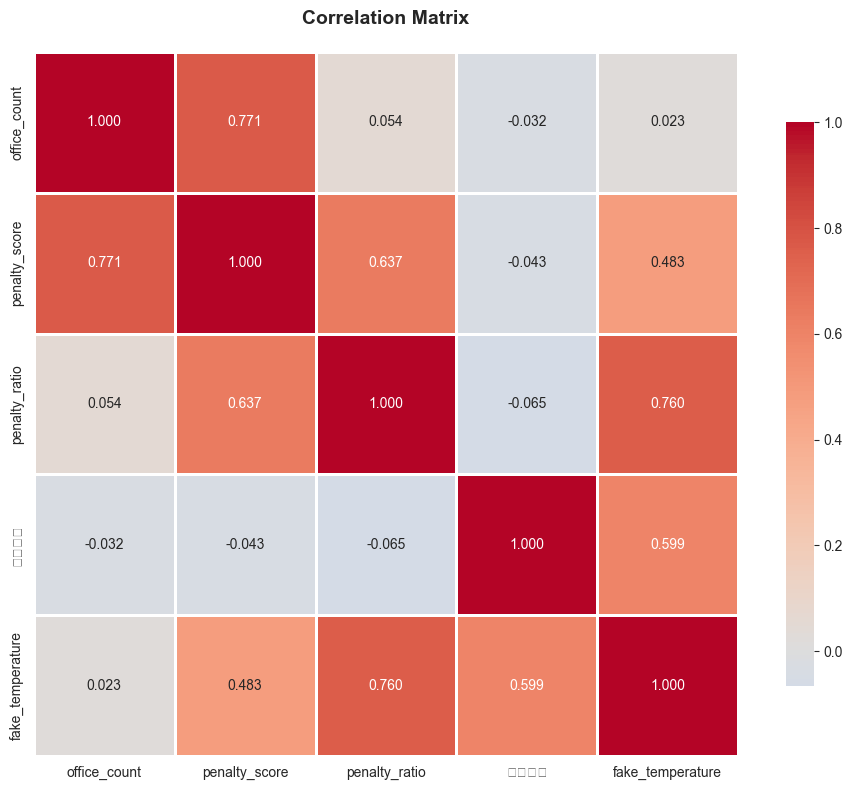

In [21]:
# 4. 상관관계 분석
correlation_cols = ['office_count', 'penalty_score', 'penalty_ratio', '경매건수', 'fake_temperature']
corr_matrix = merged_clean[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 5. 결론

In [15]:
print("\n" + "="*60)
print("주요 인사이트")
print("="*60)

most_dangerous = merged_clean.loc[merged_clean['fake_temperature'].idxmax()]
print(f"\n1. 가장 위험한 지역: {most_dangerous['region']}")
print(f"   - 허위매물 온도: {most_dangerous['fake_temperature']:.2f}")
print(f"   - 등급: {most_dangerous['grade']}")
print(f"   - 중개업소 수: {most_dangerous['office_count']:.0f}개")
print(f"   - 행정처분 비율: {most_dangerous['penalty_ratio']:.3f}")

most_safe = merged_clean.loc[merged_clean['fake_temperature'].idxmin()]
print(f"\n2. 가장 안전한 지역: {most_safe['region']}")
print(f"   - 허위매물 온도: {most_safe['fake_temperature']:.2f}")
print(f"   - 등급: {most_safe['grade']}")

high_risk_count = (merged_clean['grade'] == '고위험').sum()
print(f"\n3. 고위험 지역: {high_risk_count}개 ({high_risk_count/len(merged_clean)*100:.1f}%)")

print("\n4. 전체 지역 순위:")
summary = merged_clean[['region', 'fake_temperature', 'grade']].sort_values('fake_temperature', ascending=False)
for idx, row in summary.iterrows():
    print(f"   {row['region']}: {row['fake_temperature']:.2f} ({row['grade']})")

print("\n" + "="*60)


주요 인사이트

1. 가장 위험한 지역: 중구
   - 허위매물 온도: 82.17
   - 등급: 고위험
   - 중개업소 수: 600개
   - 행정처분 비율: 1.013

2. 가장 안전한 지역: 용산구
   - 허위매물 온도: 10.63
   - 등급: 안전

3. 고위험 지역: 1개 (4.0%)

4. 전체 지역 순위:
   중구: 82.17 (고위험)
   강북구: 53.53 (주의)
   관악구: 52.70 (주의)
   강서구: 48.34 (주의)
   송파구: 47.76 (주의)
   구로구: 46.25 (주의)
   성북구: 40.29 (주의)
   동작구: 39.87 (주의)
   강남구: 39.35 (주의)
   도봉구: 35.13 (주의)
   중랑구: 34.46 (주의)
   서초구: 32.75 (안전)
   금천구: 30.78 (안전)
   서대문구: 30.20 (안전)
   성동구: 27.55 (안전)
   은평구: 26.51 (안전)
   동대문구: 24.59 (안전)
   강동구: 22.48 (안전)
   영등포구: 22.26 (안전)
   양천구: 20.80 (안전)
   마포구: 17.91 (안전)
   종로구: 16.04 (안전)
   노원구: 15.67 (안전)
   광진구: 14.52 (안전)
   용산구: 10.63 (안전)

